# RASID — AI-Powered Early Warning System for Supply Chain Disruption Risk

## Project Objective

RASID is a machine learning project that predicts the next day's supply chain disruption risk using the previous 7 days of supplier and operational data.

The target variable is `Risk_Level`, with three classes:

* High
* Medium
* Low

The project uses time-series data from multiple suppliers and compares different machine learning models to select a final model based on validation and test performance.


## 1. Import Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

## 2. Data Loading and Preparation

In [ ]:
# Load the dataset
df = pd.read_csv("supply_20000.csv")

# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort data by supplier and time
df = df.sort_values(
    ["Supplier_ID", "Timestamp"]
).reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (20000, 13)


## 3. Data Quality & Exploration

In [63]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Timestamp                        0
Supplier_ID                      0
Port_Congestion                  0
geopolitical_risk                0
weather_severity                 0
Supplier_Reliability             0
Supplier_Capacity_Utilization    0
Inventory_Level                  0
Demand_Volatility                0
Lead_Time_Days                   0
Shipping_Cost_Index              0
Risk_Level                       0
Risk_Score                       0
dtype: int64


In [64]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [65]:
# Check for duplicate supplier timestamps
duplicate_supplier_timestamp = df.duplicated(
    subset=["Supplier_ID", "Timestamp"]
).sum()

print("Duplicate Supplier_ID + Timestamp:", duplicate_supplier_timestamp)

Duplicate Supplier_ID + Timestamp: 0


In [25]:
# Calculate the time difference between consecutive observations
# for each supplier
time_diff = (
    df.groupby("Supplier_ID")["Timestamp"]
      .diff()
)

print("Most common time differences:")
print(time_diff.value_counts().head(20))

Most common time differences:
Timestamp
1 days    19950
Name: count, dtype: int64


In [26]:
# Count the number of observations for each supplier
supplier_counts = df["Supplier_ID"].value_counts()

print("Number of suppliers:", supplier_counts.size)

print("\nObservations per supplier:")
print(supplier_counts.describe())

print("\nMinimum observations for one supplier:",
      supplier_counts.min())

print("\nMaximum observations for one supplier:",
      supplier_counts.max())

Number of suppliers: 50

Observations per supplier:
count     50.0
mean     400.0
std        0.0
min      400.0
25%      400.0
50%      400.0
75%      400.0
max      400.0
Name: count, dtype: float64

Minimum observations for one supplier: 400

Maximum observations for one supplier: 400


In [66]:
# Display the number of observations in each risk class
print("Risk_Level distribution:")
print(df["Risk_Level"].value_counts())

# Display the percentage of each risk class
print("\nRisk_Level percentages:")
print(
    df["Risk_Level"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

Risk_Level distribution:
Risk_Level
Low       8000
Medium    7000
High      5000
Name: count, dtype: int64

Risk_Level percentages:
Risk_Level
Low       40.0
Medium    35.0
High      25.0
Name: proportion, dtype: float64


## 4. Temporal Data Split
Data is split chronologically for each supplier into 60% training, 20% validation, and 20% test sets.

In [70]:
# Define split ratios
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

train_parts = []
val_parts = []
test_parts = []

# Split each supplier independently by time
for supplier_id, supplier_df in df.groupby("Supplier_ID"):

    # Keep observations in chronological order
    supplier_df = supplier_df.sort_values("Timestamp").reset_index(drop=True)

    n = len(supplier_df)

    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    train_parts.append(supplier_df.iloc[:train_end])
    val_parts.append(supplier_df.iloc[train_end:val_end])
    test_parts.append(supplier_df.iloc[val_end:])

# Combine all suppliers
train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (12000, 13)
Validation shape: (4000, 13)
Test shape: (4000, 13)


# 5. Time-Series Feature Engineering

Use the previous 7 observations from the same supplier to predict the next `Risk_Level`.

In [71]:
# Features used by the models
feature_cols = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]

# Target to predict
target_col = "Risk_Level"

print("Number of features:", len(feature_cols))
print("Features:")
print(feature_cols)

print("\nTarget:", target_col)

Number of features: 9
Features:
['Port_Congestion', 'geopolitical_risk', 'weather_severity', 'Supplier_Reliability', 'Supplier_Capacity_Utilization', 'Inventory_Level', 'Demand_Volatility', 'Lead_Time_Days', 'Shipping_Cost_Index']

Target: Risk_Level


In [ ]:
WINDOW = 7

### Create Time-Series Windows

Create 7-observation windows for each supplier and assign each target to Train, Validation, or Test.

In [73]:
# Combine the split labels with the original dataset
df_split = df.copy()

# Mark each observation according to its temporal split
df_split["Split"] = "Train"

df_split.loc[
    df_split["Timestamp"].isin(val_df["Timestamp"]),
    "Split"
] = "Validation"

df_split.loc[
    df_split["Timestamp"].isin(test_df["Timestamp"]),
    "Split"
] = "Test"

# Store all generated windows
X_train = []
y_train = []

X_val = []
y_val = []

X_test = []
y_test = []

train_suppliers = []
val_suppliers = []
test_suppliers = []

train_dates = []
val_dates = []
test_dates = []

# Create windows separately for each supplier
for supplier_id, supplier_df in df_split.groupby("Supplier_ID"):

    supplier_df = supplier_df.sort_values("Timestamp").reset_index(drop=True)

    features = supplier_df[feature_cols].to_numpy()
    targets = supplier_df[target_col].to_numpy()
    splits = supplier_df["Split"].to_numpy()
    dates = supplier_df["Timestamp"].to_numpy()

    # 7 previous observations → next observation
    for i in range(WINDOW, len(supplier_df)):

        window_data = features[i - WINDOW:i]
        target = targets[i]
        target_split = splits[i]
        target_date = dates[i]

        if target_split == "Train":
            X_train.append(window_data)
            y_train.append(target)
            train_suppliers.append(supplier_id)
            train_dates.append(target_date)

        elif target_split == "Validation":
            X_val.append(window_data)
            y_val.append(target)
            val_suppliers.append(supplier_id)
            val_dates.append(target_date)

        elif target_split == "Test":
            X_test.append(window_data)
            y_test.append(target)
            test_suppliers.append(supplier_id)
            test_dates.append(target_date)

# Convert lists to NumPy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

X_test = np.array(X_test)
y_test = np.array(y_test)

train_suppliers = np.array(train_suppliers)
val_suppliers = np.array(val_suppliers)
test_suppliers = np.array(test_suppliers)

train_dates = np.array(train_dates)
val_dates = np.array(val_dates)
test_dates = np.array(test_dates)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11650, 7, 9)
X_val shape: (4000, 7, 9)
X_test shape: (4000, 7, 9)

y_train shape: (11650,)
y_val shape: (4000,)
y_test shape: (4000,)


# 6. Target Preparation

Encode the risk levels into numeric labels for model training.

In [74]:
# Encode Risk_Level for model training
label_map = {
    "High": 0,
    "Low": 1,
    "Medium": 2
}

y_train_encoded = pd.Series(y_train).map(label_map).to_numpy()
y_val_encoded = pd.Series(y_val).map(label_map).to_numpy()
y_test_encoded = pd.Series(y_test).map(label_map).to_numpy()

### Prepare Features for Tree-Based Models

Flatten the 7 × 9 time-series windows into 63 features.

In [38]:
# Flatten the 7 × 9 windows into 63 features
# This is only needed for tree-based models

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_val_flat shape:", X_val_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (11650, 63)
X_val_flat shape: (4000, 63)
X_test_flat shape: (4000, 63)


# 7. Model Training & Validation

Train and evaluate different machine learning models using the training and validation sets.

### 7.1 Decision Tree

Train a Decision Tree classifier as a baseline model.

In [93]:
# ============================================================
# 7.1 DECISION TREE
# ============================================================

# Create the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(
    X_train_flat,
    y_train_encoded
)

# Predictions
y_train_pred_dt = dt_model.predict(X_train_flat)
y_val_pred_dt = dt_model.predict(X_val_flat)

# Calculate metrics
dt_train_accuracy = accuracy_score(
    y_train_encoded,
    y_train_pred_dt
)

dt_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_dt
)

dt_val_precision = precision_score(
    y_val_encoded,
    y_val_pred_dt,
    average="macro"
)

dt_val_recall = recall_score(
    y_val_encoded,
    y_val_pred_dt,
    average="macro"
)

dt_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_dt,
    average="macro"
)

dt_train_f1 = f1_score(
    y_train_encoded,
    y_train_pred_dt,
    average="macro"
)

# Display results
print("Decision Tree Results")
print("=" * 50)

print(f"Training Accuracy          : {dt_train_accuracy:.4f}")
print(f"Training F1 (Macro)        : {dt_train_f1:.4f}")
print(f"Validation Accuracy        : {dt_val_accuracy:.4f}")
print(f"Validation Precision (Macro): {dt_val_precision:.4f}")
print(f"Validation Recall (Macro)   : {dt_val_recall:.4f}")
print(f"Validation F1 (Macro)       : {dt_val_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred_dt,
        target_names=["High", "Low", "Medium"]
    )
)

Decision Tree Results
Training Accuracy          : 1.0000
Training F1 (Macro)        : 1.0000
Validation Accuracy        : 0.5962
Validation Precision (Macro): 0.6029
Validation Recall (Macro)   : 0.5993
Validation F1 (Macro)       : 0.6010

Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.62      0.63      1030
         Low       0.66      0.65      0.66      1462
      Medium       0.51      0.53      0.52      1508

    accuracy                           0.60      4000
   macro avg       0.60      0.60      0.60      4000
weighted avg       0.60      0.60      0.60      4000



### 7.2 Random Forest

Train a Random Forest classifier using the same training and validation sets.

In [94]:
# ============================================================
# 7.2 RANDOM FOREST
# ============================================================

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(
    X_train_flat,
    y_train_encoded
)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_flat)
y_val_pred_rf = rf_model.predict(X_val_flat)

# Calculate metrics
rf_train_accuracy = accuracy_score(
    y_train_encoded,
    y_train_pred_rf
)

rf_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_rf
)

rf_val_precision = precision_score(
    y_val_encoded,
    y_val_pred_rf,
    average="macro"
)

rf_val_recall = recall_score(
    y_val_encoded,
    y_val_pred_rf,
    average="macro"
)

rf_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_rf,
    average="macro"
)

rf_train_f1 = f1_score(
    y_train_encoded,
    y_train_pred_rf,
    average="macro"
)

# Display results
print("Random Forest Results")
print("=" * 50)

print(f"Training Accuracy           : {rf_train_accuracy:.4f}")
print(f"Training F1 (Macro)         : {rf_train_f1:.4f}")
print(f"Validation Accuracy         : {rf_val_accuracy:.4f}")
print(f"Validation Precision (Macro): {rf_val_precision:.4f}")
print(f"Validation Recall (Macro)   : {rf_val_recall:.4f}")
print(f"Validation F1 (Macro)       : {rf_val_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred_rf,
        target_names=["High", "Low", "Medium"]
    )
)

Random Forest Results
Training Accuracy           : 0.9999
Training F1 (Macro)         : 0.9999
Validation Accuracy         : 0.6895
Validation Precision (Macro): 0.7022
Validation Recall (Macro)   : 0.6871
Validation F1 (Macro)       : 0.6932

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.66      0.71      1030
         Low       0.75      0.76      0.76      1462
      Medium       0.59      0.64      0.62      1508

    accuracy                           0.69      4000
   macro avg       0.70      0.69      0.69      4000
weighted avg       0.69      0.69      0.69      4000



### 7.3 XGBoost

Train an XGBoost classifier using the same training and validation sets.

In [95]:
# ============================================================
# 7.3 XGBOOST
# ============================================================

# Create the model
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss"
)

# Train the model
xgb_model.fit(
    X_train_flat,
    y_train_encoded
)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_flat)
y_val_pred_xgb = xgb_model.predict(X_val_flat)

# Calculate metrics
xgb_train_accuracy = accuracy_score(
    y_train_encoded,
    y_train_pred_xgb
)

xgb_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_xgb
)

xgb_val_precision = precision_score(
    y_val_encoded,
    y_val_pred_xgb,
    average="macro"
)

xgb_val_recall = recall_score(
    y_val_encoded,
    y_val_pred_xgb,
    average="macro"
)

xgb_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_xgb,
    average="macro"
)

xgb_train_f1 = f1_score(
    y_train_encoded,
    y_train_pred_xgb,
    average="macro"
)

# Display results
print("XGBoost Results")
print("=" * 50)

print(f"Training Accuracy           : {xgb_train_accuracy:.4f}")
print(f"Training F1 (Macro)         : {xgb_train_f1:.4f}")
print(f"Validation Accuracy         : {xgb_val_accuracy:.4f}")
print(f"Validation Precision (Macro): {xgb_val_precision:.4f}")
print(f"Validation Recall (Macro)   : {xgb_val_recall:.4f}")
print(f"Validation F1 (Macro)       : {xgb_val_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred_xgb,
        target_names=["High", "Low", "Medium"]
    )
)

XGBoost Results
Training Accuracy           : 0.9967
Training F1 (Macro)         : 0.9968
Validation Accuracy         : 0.6985
Validation Precision (Macro): 0.7095
Validation Recall (Macro)   : 0.6977
Validation F1 (Macro)       : 0.7026

Classification Report:
              precision    recall  f1-score   support

        High       0.77      0.68      0.72      1030
         Low       0.75      0.77      0.76      1462
      Medium       0.61      0.64      0.62      1508

    accuracy                           0.70      4000
   macro avg       0.71      0.70      0.70      4000
weighted avg       0.70      0.70      0.70      4000



# 8. Model Comparison & Selection

Compare the models based on validation performance.

In [97]:
# ============================================================
# 8. MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Training Accuracy": [
        dt_train_accuracy,
        rf_train_accuracy,
        xgb_train_accuracy
    ],
    "Training F1 (Macro)": [
        dt_train_f1,
        rf_train_f1,
        xgb_train_f1
    ],
    "Validation Accuracy": [
        dt_val_accuracy,
        rf_val_accuracy,
        xgb_val_accuracy
    ],
    "Validation Precision (Macro)": [
        dt_val_precision,
        rf_val_precision,
        xgb_val_precision
    ],
    "Validation Recall (Macro)": [
        dt_val_recall,
        rf_val_recall,
        xgb_val_recall
    ],
    "Validation F1 (Macro)": [
        dt_val_f1,
        rf_val_f1,
        xgb_val_f1
    ]
})

display(
    model_comparison.round(4)
)

,Model,Training Accuracy,Training F1 (Macro),Validation Accuracy,Validation Precision (Macro),Validation Recall (Macro),Validation F1 (Macro)
0,Decision Tree,1.0000,1.0000,0.5962,0.6029,0.5993,0.6010
1,Random Forest,0.9999,0.9999,0.6895,0.7022,0.6871,0.6932
2,XGBoost,0.9967,0.9968,0.6985,0.7095,0.6977,0.7026


### Select the Final Model

Select the model with the highest validation Macro F1 score.

In [99]:
# Select the model with the highest validation Macro F1
best_model_name = model_comparison.loc[
    model_comparison["Validation F1 (Macro)"].idxmax(),
    "Model"
]

print("Selected model:", best_model_name)

Selected model: XGBoost


# 9. Final Model Evaluation

Evaluate the selected model on the unseen test set.

In [100]:
# ============================================================
# 9. FINAL MODEL EVALUATION
# ============================================================

# Map model names to trained models
model_dict = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Select the best model
final_model = model_dict[best_model_name]

print("Final model:", best_model_name)

Final model: XGBoost


### 9.1 Test Set Evaluation



In [102]:
# Make predictions on the unseen test set
y_test_pred = final_model.predict(X_test_flat)

# Calculate test metrics
test_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

test_precision = precision_score(
    y_test_encoded,
    y_test_pred,
    average="macro"
)

test_recall = recall_score(
    y_test_encoded,
    y_test_pred,
    average="macro"
)

test_f1 = f1_score(
    y_test_encoded,
    y_test_pred,
    average="macro"
)

# Display results
print("Final Model Test Results")
print("=" * 50)

print(f"Test Accuracy            : {test_accuracy:.4f}")
print(f"Test Precision (Macro)   : {test_precision:.4f}")
print(f"Test Recall (Macro)      : {test_recall:.4f}")
print(f"Test F1 (Macro)          : {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=["High", "Low", "Medium"]
    )
)

Final Model Test Results
Test Accuracy            : 0.7103
Test Precision (Macro)   : 0.7182
Test Recall (Macro)      : 0.7125
Test F1 (Macro)          : 0.7151

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.74      0.76      1051
         Low       0.76      0.78      0.77      1489
      Medium       0.61      0.62      0.62      1460

    accuracy                           0.71      4000
   macro avg       0.72      0.71      0.72      4000
weighted avg       0.71      0.71      0.71      4000



### 9.2 Confusion Matrix

Visualize the classification results of the final model on the test set.

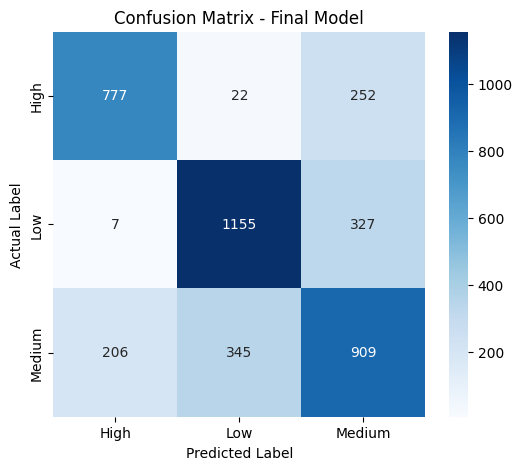

In [103]:
# Confusion Matrix
cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Final Model")
plt.show()

# 10. Model Interpretation

Identify the features that contribute most to the final model's predictions.

In [111]:
# Get feature importance from the final model
feature_importance = final_model.feature_importances_

# Create feature names for the 7-day windows
feature_names = []

for day in range(1, WINDOW + 1):
    for feature in feature_cols:
        feature_names.append(f"{feature}_{day}")

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Aggregate importance across the 7 days
importance_df["Original Feature"] = (
    importance_df["Feature"]
    .str.rsplit("_", n=1)
    .str[0]
)

aggregated_importance = (
    importance_df
    .groupby("Original Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print("Feature Importance:")
print(aggregated_importance.round(4))

Feature Importance:
Original Feature
geopolitical_risk                0.2593
Port_Congestion                  0.1433
Supplier_Reliability             0.1132
Demand_Volatility                0.1038
weather_severity                 0.1027
Supplier_Capacity_Utilization    0.0718
Shipping_Cost_Index              0.0699
Lead_Time_Days                   0.0681
Inventory_Level                  0.0679
Name: Importance, dtype: float32


### Feature Importance

Visualize the importance of each feature in the final model.

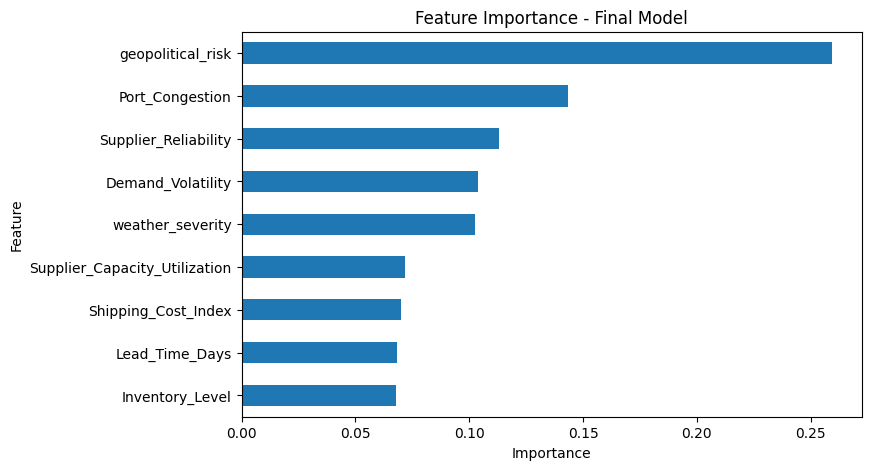

In [112]:
# Plot feature importance
plt.figure(figsize=(8, 5))

aggregated_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Final Model")

plt.show()

# 11. Save Final Model

Save the final model and its configuration for use in the RASID application.

In [121]:
# ============================================================
# 11. SAVE FINAL MODEL
# ============================================================

import os
import json

# Create artifacts folder
os.makedirs("artifacts", exist_ok=True)

# Save the final model
joblib.dump(
    final_model,
    "artifacts/model.joblib"
)

# Get validation accuracy of the selected model
validation_accuracy = model_comparison.loc[
    model_comparison["Model"] == best_model_name,
    "Validation Accuracy"
].iloc[0]

# Save model information
model_info = {
    "model": best_model_name,
    "window_size": WINDOW,
    "features": feature_cols,
    "target": target_col,
    "label_map": label_map,

    "validation_accuracy": round(
        validation_accuracy,
        4
    ),

    "validation_macro_f1": round(
        model_comparison.loc[
            model_comparison["Model"] == best_model_name,
            "Validation F1 (Macro)"
        ].iloc[0],
        4
    ),

    "test_accuracy": round(
        test_accuracy,
        4
    ),

    "test_macro_f1": round(
        test_f1,
        4
    )
}

with open(
    "artifacts/model_info.json",
    "w"
) as f:

    json.dump(
        model_info,
        f,
        indent=4
    )

print("Final model saved successfully.")
print("artifacts/model.joblib")
print("artifacts/model_info.json")

Final model saved successfully.
artifacts/model.joblib
artifacts/model_info.json
